# Generación de variables

#### Contenidos:
* [Transformación de variables numéricas](#2.1)
* [Interacción de variables categóricas](#2.2)
* [Creación de variables a partir de texto](#2.3)
* [Creación de variables a partir de fechas](#2.4)
* [Creación de variables a partir de horas](#2.5)

Importamos todas las librerías que vamos a utilizar.

In [16]:
# %load ../../standard_import.txt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import category_encoders as ce
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn import neighbors, model_selection, tree
from sklearn.preprocessing import PolynomialFeatures

pd.set_option('display.notebook_repr_html', False)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
pd.set_option('display.max_seq_items', None)
 
#%config InlineBackend.figure_formats = {'pdf',}
%matplotlib inline

En este Notebook vamos a aprender diferentes opciones para generar nuevas variables a partir de las originales. Las nuevas variables generadas pueden:
* Sustituir a las originales
* O ser añadidas al conjunto original de variables. 

En concreto, vamos a aprender varias opciones que permiten generar variables realizando:
* Transformaciones a las variables numéricas originales (polinomiales, logarítmicas, raíces cuadradas)
* Agregaciones de las variables numéricas originales
* Interacciones entre variables categóricas
* Uso de variables que contienen fechas y/o horas (y generación de variables a partir de ellas)

Para ello, vamos a utilizar un problema de regresión que consiste en predecir el valor de las acciones al cierre de la sesión en función de diversas variables de entrada. Los ejemplos disponibles están almacenados en el fichero *all_stocks_5yr.csv*.

In [17]:
# Lectura de los datos del problema, guardado del resultado en las variables stock (X) y stoack_output(y)
stock = pd.read_csv('all_stocks_5yr.csv', delimiter=',')
stock.dropna(axis=0, inplace = True)
atSalida = 'close'
atEntrada = ['open','high','low','volume']

stock_output = stock[atSalida].copy()
stock.drop(atSalida, axis=1, inplace=True)
stock = stock[atEntrada].copy()

## Transformación de variables numéricas <a class="anchor" id="2.1"></a>

Una vez leídos los datos vamos a comenzar a analizar las diferentes opciones para generar variables a partir de variables numéricas. Este es un proceso complejo puesto que depende del problema a solucionar y la generación de nuevas variables será específica en muchos casos y requerirá de dominio del problema, creatividad y un poco de experiencia. En este Notebook vamos a ver algunos ejemplos y algunas transformaciones habituales.

En primer lugar, podemores crear variables numéricas mediante la generación de variables polinómicas para que los modelos lineales pudieran abordar problemas de predicción no lineales. La clase de Scikit-learn que permite generar variables polinómicas a partir de variables numéricas es [*PolynomialFeatures*](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html). 

In [18]:
# Generamos los conjuntos de entrenamiento y de test
X_train, X_test, y_train, y_test = train_test_split(stock, stock_output, test_size=0.2, random_state=12)

# Creamos una Pipeline en la que generamos variables polinómicas de grado 2, estandarizamos los datos y aprendemos una regresión lineal
pipePoly = Pipeline([('polynomial', PolynomialFeatures(degree=2)),('scaler', StandardScaler()),('regressor', LinearRegression())])
# Entrenamos la Pipeline
pipePoly.fit(X_train, y_train)
# Obtenemos el rendimiento en entrenamiento y en test (RMSE)
prTrain = pipePoly.predict(X_train)
errorTrain = mean_squared_error(y_train, prTrain, squared=False)
prTest = pipePoly.predict(X_test)
errorTest = mean_squared_error(y_test, prTest, squared=False)
print('El error en entrenamiento es {:.4f} y en test es {:.4f}'.format(errorTrain, errorTest))

El error en entrenamiento es 0.6829 y en test es 0.7002


Un método habitual de generación de nuevas variables es **transformar el contenido de las variables originales** para tratar de facilitar el aprendizaje posterior del modelo. Para ello, habitualmente se trata de transformar la distribución de los datos de una variable para que se parezca lo más posible a una distribución Gaussiana puesto que algunos modelos trabajan mejor con este tipo de distribución. Dos transformaciones habituales son la **logarítmica** y la de la **raíz cuadrada** ya que consiguen que la nueva variable se parezca más a una Gaussiana, ayudan a reducir el efecto de los outliers y pueden sacar a la luz relaciones entre variables que con las distribuciones originales no fueran patentes.

Para ilustrar estas transformaciones, vamos a utilizar la variable *open*.

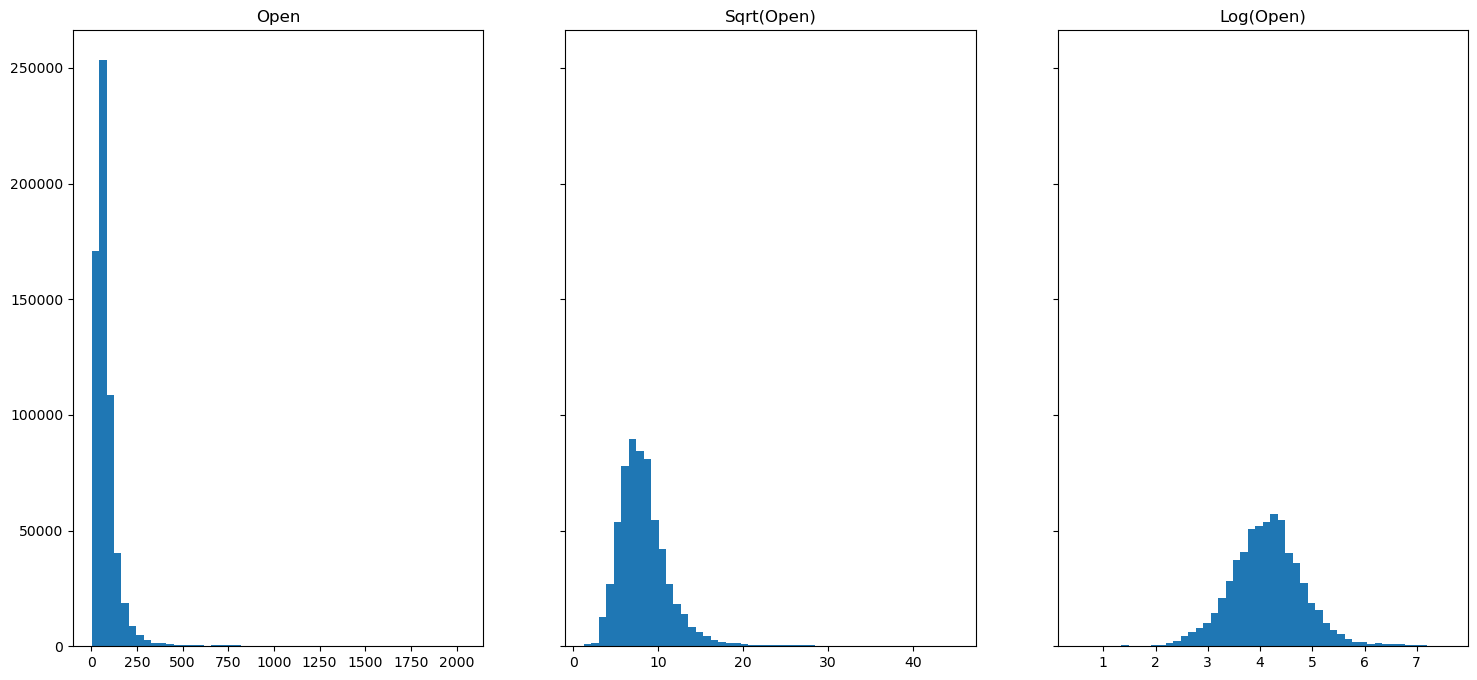

In [19]:
# Creamos una figura para mostrar la distribución original de la variable (histogramas)
  # y la distribución tras aplicar la raíz cuadrada y el logaritmo
f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(18,8))
ax1.hist(stock.open, bins=50)
ax1.set_title('Open')
ax2.hist(np.sqrt(stock.open), bins=50)
ax2.set_title('Sqrt(Open)')
ax3.hist(np.log(stock.open), bins=50)
ax3.set_title('Log(Open)');

Podemos observar cómo estas transformaciones consiguen que la distribución de los datos sea más parecida a una Gaussiana. Estas transformaciones no ayudarán al aprendizaje de modelos que sean invariantes ante la escala (como los árboles de decisión) pero si a los modelos lineales o las redes neuronales.

Ahora vamos a aplicar ambas transformaciones para generar nuevas variables y ver su efecto en el rendimiento del modelo. Comenzamos con la transformación logarítmica.

In [20]:
# Creamos una copia del dataset original
stock_log = stock.copy()
# Generamos tantas variables nuevas como variables numéricas originales (pasamos por todas porque todas son numéricas)
for v in stock.columns:
    nombreVariableNueva = 'log(' + v + ')'
    stock_log[nombreVariableNueva] = np.log(stock_log[v])
    
print(stock_log.head())

# Creamos los conjuntos de entrenamiento y de test utilizando la misma semilla de antes
X_train, X_test, y_train, y_test = train_test_split(stock_log, stock_output, test_size=0.2, random_state=12)

# Creamos la misma Pipeline que antes
pipePoly = Pipeline([('polynomial', PolynomialFeatures(degree=2)),('scaler', StandardScaler()),('regressor', LinearRegression())])
# Entrenamos la Pipeline
pipePoly.fit(X_train, y_train)
# Obtenemos el rendimiento en entrenamiento y en test (RMSE)
prTrain = pipePoly.predict(X_train)
errorTrain = mean_squared_error(y_train, prTrain, squared=False)
prTest = pipePoly.predict(X_test)
errorTest = mean_squared_error(y_test, prTest, squared=False)
print('El error en entrenamiento es {:.4f} y en test es {:.4f}'.format(errorTrain, errorTest))

    open   high    low    volume  log(open)  log(high)  log(low)  log(volume)
0  15.07  15.12  14.63   8407500   2.712706   2.716018  2.683074    15.944635
1  14.89  15.01  14.26   8882000   2.700690   2.708717  2.657458    15.999537
2  14.45  14.51  14.10   8126000   2.670694   2.674838  2.646175    15.910579
3  14.30  14.94  14.25  10259500   2.660260   2.704042  2.656757    16.143715
4  14.94  14.96  13.16  31879900   2.704042   2.705380  2.577182    17.277486
El error en entrenamiento es 0.6778 y en test es 0.6979


Podemos observar que el error ha bajado. 

Como hemos visto en las prácticas, para implementar nuestros propios métodos de preparación de datos de forma que sean compatibles con Scikit-learn (para poder utilizar las *Pipelines*, *GridSearchCV*, etc...), Scikit-learn nos ofrece la clase llamada [*TransformerMixin*](https://scikit-learn.org/stable/modules/generated/sklearn.base.TransformerMixin.html). Vamos a realizar una clase para hacer la transformación logarítmica (para el resto de técnicas se podría realizar un proceso similar y crear las clases necesarias para poder utilizarlas de forma automatizada).

In [21]:
# Importamos la clase TransformerMixin
from sklearn.base import TransformerMixin

# Creamos la clase de detección y tratamiento de Outliers
class log_transformer(TransformerMixin):

    # Constructor de la clase
    def __init__(self, columns=None):
        self.columns = columns
    
    # Método fit
    def fit(self, X, y=None):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        # Si no se han especificado variables a tratar vamos a tratar todas
        if self.columns == None:
            self.columns = X.columns
        # Devolvemos el objeto modificado (en este caso solamente ha aprendido qué variables se deben tratar)
        return self

    # Método transform
    def transform(self, X):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        # Creamos una copia del DataFrame X para no perder los datos originales
        X_log = X.copy()
        # Generamos tantas variables nuevas como variables numéricas originales (pasamos por todas porque todas son numéricas)
        for v in self.columns:
            nombreVariableNueva = 'log(' + v + ')'
            X_log[nombreVariableNueva] = np.log(X_log[v])
        # Devolvemos el DataFrame transformado
        return X_log
    
    # Método para asignar los valores de los híper-parámetros y que, de este modo, 
        # podamos aplicar GridSearchCV sobre un objeto de esta clase
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    # Método para obtener los valores de los híper-parámetros que queramos del modelo (lo usa GridSearchCV al mostrar la mejor configuración)
    def get_params(self, deep=True):
        # Devolvemos los valores de los híper-parámetros del método de preparación de datos
        return {"Columnas tratadas": self.columns}

In [22]:
# Generamos los conjuntos de entrenamiento y de test
X_train, X_test, y_train, y_test = train_test_split(stock, stock_output, test_size=0.2, random_state=12)

# Creamos la misma Pipeline que antes pero inluímos nuestro transformador a logaritmos en primer lugar
pipeLogPoly = Pipeline([('logTransf', log_transformer()),('polynomial', PolynomialFeatures(degree=2)),('scaler', StandardScaler()),('regressor', LinearRegression())])
# Entrenamos la Pipeline
pipeLogPoly.fit(X_train, y_train)
# Obtenemos el rendimiento en entrenamiento y en test (RMSE)
prTrain = pipeLogPoly.predict(X_train)
errorTrain = mean_squared_error(y_train, prTrain, squared=False)
prTest = pipeLogPoly.predict(X_test)
errorTest = mean_squared_error(y_test, prTest, squared=False)
print('El error en entrenamiento es {:.4f} y en test es {:.4f}'.format(errorTrain, errorTest))

El error en entrenamiento es 0.6778 y en test es 0.6979


Vamos a ver qué pasa con si realizamos la transformación aplicando la raíz cuadrada.

In [26]:
# Creamos una copia del dataset original
stock_sqrt = stock.copy()
# Generamos tantas variables nuevas como variables numéricas originales (pasamos por todas porque todas son numéricas)
for v in stock.columns:
    nombreVariableNueva = 'sqrt(' + v + ')'
    stock_sqrt[nombreVariableNueva] = np.sqrt(stock_sqrt[v])
    
print(stock_sqrt.head())

# Creamos los conjuntos de entrenamiento y de test utilizando la misma semilla de antes
X_train, X_test, y_train, y_test = train_test_split(stock_sqrt, stock_output, test_size=0.2, random_state=12)

# Creamos la misma Pipeline que antes
pipePoly = Pipeline([('polynomial', PolynomialFeatures(degree=2)),('scaler', StandardScaler()),('regressor', LinearRegression())])
# Entrenamos la Pipeline
pipePoly.fit(X_train, y_train)
# Obtenemos el rendimiento en entrenamiento y en test (RMSE)
prTrain = pipePoly.predict(X_train)
errorTrain = mean_squared_error(y_train, prTrain, squared=False)
prTest = pipePoly.predict(X_test)
errorTest = mean_squared_error(y_test, prTest, squared=False)
print('El error en entrenamiento es {:.4f} y en test es {:.4f}'.format(errorTrain, errorTest))

    open   high    low    volume  sqrt(open)  sqrt(high)  sqrt(low)  \
0  15.07  15.12  14.63   8407500    3.882010    3.888444   3.824918   
1  14.89  15.01  14.26   8882000    3.858756    3.874274   3.776242   
2  14.45  14.51  14.10   8126000    3.801316    3.809199   3.754997   
3  14.30  14.94  14.25  10259500    3.781534    3.865230   3.774917   
4  14.94  14.96  13.16  31879900    3.865230    3.867816   3.627671   

   sqrt(volume)  
0   2899.568933  
1   2980.268444  
2   2850.613969  
3   3203.045426  
4   5646.228830  
El error en entrenamiento es 0.6780 y en test es 0.6982


Observamos que el error es menor que con el conjunto de variables originales pero mayor que con la transformación logarítmica.

Otra opción que se puede hacer para crear nuevas variables es aplicar operaciones sobre las mismas que impliquen obtener variables que puedan aportar más información que las anteriores. Este proceso implica tener un gran conocimiento del problema a resolver puesto que para crear este tipo de variables se debe conocer si tienen sentido.

Como ejemplo vamos a crear la diferencia entre el valor más alto y más bajo de las acciones de una compañía en una sesión. 

In [27]:
stock['diferencia_HighLow'] = stock.high - stock.low
stock.head()

    open   high    low    volume  diferencia_HighLow
0  15.07  15.12  14.63   8407500                0.49
1  14.89  15.01  14.26   8882000                0.75
2  14.45  14.51  14.10   8126000                0.41
3  14.30  14.94  14.25  10259500                0.69
4  14.94  14.96  13.16  31879900                1.80

Evidentemente, se podrían generar nuevas variables aplicando operaciones más complejas y con más variables de entrada involucradas.

## Interacción de variables categóricas <a class="anchor" id="2.2"></a>

Al trabajar con variables categóricas, una de las formas más sencillas y habituales de crear nuevas variables es la de combinar las variables categóricas originales. Por ejemplo, si tenemos las variables categóricas del sexo y el nivel académico, podemos generar la variable que las combine (sexo_nivelAcademico). Este tipo de variable se llama comúnmente interacción puesto que puede capturar las interacciones entre variables categóricas.

En general, se suelen crear variables que capturen la interacción entre parejas de variables categóricas. Se pueden generar nuevas variables que capturen las interacciones entre tres o más variables pero es menos común.

Para ilustrar la generación de este tipo de variables vamos a utilizar un ejemplo creado manualmente.

In [28]:
# Creamos un conjunto de datos
dfCategorical = pd.DataFrame([['A', 'Mujer','Navarra'], ['B', 'Hombre','Aragón'], ['C', 'Mujer','País Vasco'], ['D', 'Hombre','La Rioja']], columns=['Nivel', 'Sexo', 'Provincia'])
dfCategorical.head()

  Nivel    Sexo   Provincia
0     A   Mujer     Navarra
1     B  Hombre      Aragón
2     C   Mujer  País Vasco
3     D  Hombre    La Rioja

In [29]:
# Nombres de las variables categóricas a combinar
variablesInteracciones = ['Nivel', 'Sexo','Provincia']

# Creamos un nuevo DataFrame para almacenar las nuevas variables (sus nombres serán los originales combinados con _)
interacciones = pd.DataFrame()
for i in range(len(variablesInteracciones)):
    for j in range(i+1, len(variablesInteracciones)):
        interacciones[variablesInteracciones[i]+"_"+variablesInteracciones[j]] = dfCategorical[variablesInteracciones[i]] + "_" + dfCategorical[variablesInteracciones[j]]

# Añadimos las nuevas variables a las originales y mostramos el DataFrame final
dfCategorical_interacciones = pd.concat([dfCategorical, interacciones], axis=1)
print(dfCategorical_interacciones.head(5))

  Nivel    Sexo   Provincia Nivel_Sexo Nivel_Provincia    Sexo_Provincia
0     A   Mujer     Navarra    A_Mujer       A_Navarra     Mujer_Navarra
1     B  Hombre      Aragón   B_Hombre        B_Aragón     Hombre_Aragón
2     C   Mujer  País Vasco    C_Mujer    C_País Vasco  Mujer_País Vasco
3     D  Hombre    La Rioja   D_Hombre      D_La Rioja   Hombre_La Rioja


A partir de este conjunto de datos, podríamos transformarlas a variables numéricas aplicando cualquier método de codificación de los que vimos en temas anteriores.

In [30]:
# Ejemplo con la codificación ordinal (pero podría ser cualquier otra)
encoder = ce.OrdinalEncoder()
dfCategorical_interacciones = encoder.fit_transform(dfCategorical_interacciones)-1 # -1 para que los valores empiecen en 0
dfCategorical_interacciones.head()

   Nivel  Sexo  Provincia  Nivel_Sexo  Nivel_Provincia  Sexo_Provincia
0      0     0          0           0                0               0
1      1     1          1           1                1               1
2      2     0          2           2                2               2
3      3     1          3           3                3               3

## Creación de variables a partir de texto <a class="anchor" id="2.3"></a>

Es frecuente que en el problema a abordar haya variables cuyo contenido sea una cadena de texto que podría ser interesante descomponer en varias sub-cadenas que ofrezcan información interesante. Algunos ejemplos comunes son:
* Números de usuario: '123-45-6789'
* Números de teléfono: '948 987654'
* Direcciones: 'Rio Ega, Nº7, 1A, Estella, Navarra, España'
* Direcciones de Internet: 'http://www.kaggle.com'
* Códigos de producto: '0 36000 29145 2'

Este tipo de variables a menudo tiene algún tipo de estructura de la que podemos obtener información. Los teléfonos, por ejemplo, tienen el prefijo de la provincia que ayudan a localizar el origen de una llamada.

El *str accessor* permite aplicar métodos de cadenas de texto como *split* y crear directamente nuevas variables. Veamos dos ejemplos de su uso.

In [31]:
# Creamos un DataFrame con números de teléfono
df = pd.DataFrame(['948 123456', '941 456789', '943 159483'], columns=['Telefono'])
df.head()

     Telefono
0  948 123456
1  941 456789
2  943 159483

In [32]:
df[["prefijo", "numero"]] = (    # Creamos dos nuevas variables llamadas prefijo y numero
    df["Telefono"]               # a partir de la variable Telefono
    .str                         # utilizando el string accessor
    .split(" ", expand=True)     # dividiendo el string por el espacio en blanco " " y expandiendo el resultado en columnas diferentes (las nuevas variables)
)

# Mostramos el nuevo DataFrame
df.head()

     Telefono prefijo  numero
0  948 123456     948  123456
1  941 456789     941  456789
2  943 159483     943  159483

In [33]:
# Creamos un DataFrame con direcciones
df = pd.DataFrame(['Rio Ega, Nº7, 1A, Estella, Navarra, España'], columns=['Direccion'])

df[["calle", "numero", "piso", 'ciudad', "provincia", "pais"]] = (  # Creamos 6 nuevas variables
    df["Direccion"]              # a partir de la variable Direccion
    .str                         #  utilizando el string accessor
    .split(",", expand=True)     # dividiendo el string por la coma y expandiendo el resultado en columnas diferentes (las nuevas variables)
)
# Dividimos la nueva variable por el º y nos quedamos con la segunda parte (el número)
df.numero = int(df.numero.str.split('º')[0][1])
# Mostramos el nuevo DataFrame
df.head()

                                    Direccion    calle  numero piso    ciudad  \
0  Rio Ega, Nº7, 1A, Estella, Navarra, España  Rio Ega       7   1A   Estella   

  provincia     pais  
0   Navarra   España  

## Creación de variables a partir de fechas <a class="anchor" id="2.4"></a>

En un problema nos podemos encontrar variables que contengan fechas y podemos generar nuevas variables a partir de ellas. Para ello, podemos utilizar la funcionalidad ofrecida en la librería [*datetime*](https://docs.python.org/es/3/library/datetime.html) de Python. Para que podamos utilizar dicha funcionalidad, primero se deben transformar los valores de la variable a al formato *datetime* mediante la función [*to_datetime*](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.to_datetime.html) de Pandas.

Para ilustrar la creación de variables a partir de fechas, vamos a utilizar de nuevo el dataset de predicción del valor de las acciones al cierre de la sesión. En este caso, también vamos a leer el contenido de la variable *date* que contiene la información del día en el que se celebró la sesión de la que se han recogido los datos.

In [34]:
# Lectura de los datos del problema, guardado del resultado en las variables stock_date (X) y stoack_output(y)
stock_date = pd.read_csv('all_stocks_5yr.csv', delimiter=',')
stock_date.dropna(axis=0, inplace = True)
atSalida = 'close'
atEntrada = ['open','high','low','volume', 'date']

stock_output = stock_date[atSalida].copy()
stock_date.drop(atSalida, axis=1, inplace=True)
stock_date = stock_date[atEntrada].copy()

stock_date.head()

    open   high    low    volume        date
0  15.07  15.12  14.63   8407500  2013-02-08
1  14.89  15.01  14.26   8882000  2013-02-11
2  14.45  14.51  14.10   8126000  2013-02-12
3  14.30  14.94  14.25  10259500  2013-02-13
4  14.94  14.96  13.16  31879900  2013-02-14

A partir de la fecha en formato *datetime* podemos obtener varias variables nuevas a través del *dt accessor* que nos digan solamente el día, el mes, el año, el nombre del día de la semana, el nombre del mes y mucha más información. Veamos ejemplos de su uso.

In [35]:
# Transformamos el tipo de datos de la variable date
stock_date.date = pd.to_datetime(stock_date.date)
# Descomponemos la fecha en día, mes y año
stock_date['Dia'] = stock_date.date.dt.day
stock_date['Mes'] = stock_date.date.dt.month
stock_date['Año'] = stock_date.date.dt.year
# Obtenemos el nombre del día y del mes
stock_date['nombreDia'] = stock_date.date.dt.day_name()
stock_date['nombreMes'] = stock_date.date.dt.month_name()
# Mostramos el nuevo DataFrame
stock_date.head()

    open   high    low    volume       date  Dia  Mes   Año  nombreDia  \
0  15.07  15.12  14.63   8407500 2013-02-08    8    2  2013     Friday   
1  14.89  15.01  14.26   8882000 2013-02-11   11    2  2013     Monday   
2  14.45  14.51  14.10   8126000 2013-02-12   12    2  2013    Tuesday   
3  14.30  14.94  14.25  10259500 2013-02-13   13    2  2013  Wednesday   
4  14.94  14.96  13.16  31879900 2013-02-14   14    2  2013   Thursday   

  nombreMes  
0  February  
1  February  
2  February  
3  February  
4  February  

Existe una librería llamada [*holidays*](https://pypi.org/project/holidays/) que nos ofrece la opción de obtener los días festivos de los diferentes paises (y en algunos casos de sus regiones).

A partir de este tipo de variables se pueden generar nuevas variables que recojan información de los últimos días (semanas) para ver tendencias, por ejemplo. Para ello, se debe establecer como índice del DataFrame la columna de la fecha (métodos [*set_index*](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.set_index.html) y [*reset_index*](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.reset_index.html)) y ordenarlo (método [*sort_index*](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sort_index.html). Luego se debe utilizar el método [*rolling*](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) al que se le pasa el período sobre el que operar (para días y semanas se debe pasar 'xd' y 'xs' donde x es el número de días/semanas a tener en cuenta). También se puede tener en cuenta otros periodos de tiempo. Debemos tener en cuenta que se tiene en cuenta el ejemplo utilizado para dar comienzo a la ventana temporal.

Vamos a ver un ejemplo de cómo calcular la media, el máximo y el mínimo valor de las acciones de una empresa en los últimos 3 días. Evidentemente, se podrían calcular otras agregaciones de los valores y de otros periodos de tiempo.

In [36]:
# Leemos los datos del problema y tenemos en cuenta todas las variables de entrada
stock_date = pd.read_csv('all_stocks_5yr.csv', delimiter=',')
stock_date.dropna(axis=0, inplace = True)
atSalida = 'close'
stock_output = stock_date[atSalida].copy()
stock_date.drop(atSalida, axis=1, inplace=True)
# Transformamos la fecha a datetime
stock_date.date = pd.to_datetime(stock_date.date)

# Asignamos como índice la variable date (fecha) y la borramos de las variables de entrada: set_index('date', drop=True)
    # no borramos el índice original: reset_index()
    # y ordenamos el índice, es decir, ordenamos los datos por fecha: sort_index()
stock_date = stock_date.reset_index().set_index('date', drop=True).sort_index()

# Creamos un nuevo DataFrame en el que agrupamos los ejemplos por el nombre de la compañía: groupby('Name')
    # Tenemos en cuenta los últimos 3 días de cada ejemplo: rolling('3d')
    # Vamos a trabajar sobre la variable high: ['high']
    # Calculamos la media, el máximo y el mínimo (agg(['mean', 'max', 'min'])) de la variable high en los últimos 3 días
agregaciones3diasHigh = stock_date.groupby('Name').rolling('3d')['high'].agg(['mean', 'max', 'min'])
# Creamos los nombres de las nuevas variables
agregaciones3diasHigh.columns = ['mean_high_3d', 'max_high_3d', 'min_high_3d']

# Añadimos las nuevas variables al DataFrame original: merge
    # Hacemos la unión por nombre de la compañía y fecha: left_on = ['Name','date']
stock_date = stock_date.merge(agregaciones3diasHigh, left_on = ['Name','date'], right_index=True, how = 'left')

# Volvemos a poner el índice original de los ejemplos y los ordenamos de acuerdo al índice original
stock_date = stock_date.reset_index().set_index('index', drop=True).sort_index() 

# Finalmente borramos el campo original de la fecha y el nombre de la compañía para que podamos hacer la predicción con los nuevos datos
stock_date.drop(['date', 'Name'], axis=1, inplace=True)
# Mostramos el DataFrame con las nuevas variables
print(stock_date.head(10))

        open   high    low    volume  mean_high_3d  max_high_3d  min_high_3d
index                                                                       
0      15.07  15.12  14.63   8407500     15.120000        15.12        15.12
1      14.89  15.01  14.26   8882000     15.010000        15.01        15.01
2      14.45  14.51  14.10   8126000     14.760000        15.01        14.51
3      14.30  14.94  14.25  10259500     14.820000        15.01        14.51
4      14.94  14.96  13.16  31879900     14.803333        14.96        14.51
5      13.93  14.61  13.93  15628000     14.836667        14.96        14.61
6      14.33  14.56  14.08  11354400     14.560000        14.56        14.56
7      14.17  14.26  13.15  14725200     14.410000        14.56        14.26
8      13.62  13.95  12.90  11922100     14.256667        14.56        13.95
9      13.57  13.60  13.21   6071400     13.936667        14.26        13.60


Ahora vamos a comprobar los resultados obtenidos si tenemos en cuenta estas nuevas variables.

In [37]:
# Creamos los conjuntos de entrenamiento y de test
X_train, X_test, y_train, y_test = train_test_split(stock_date, stock_output, test_size=0.2, random_state=12)

# Creamos la misma Pipeline que al comienzo del Notebook, la entrenamos y mostramos el rendimiento
pipePoly = Pipeline([('polynomial', PolynomialFeatures(degree=2)),('scaler', StandardScaler()),('regressor', LinearRegression())])
pipePoly.fit(X_train, y_train)

prTrain = pipePoly.predict(X_train)
errorTrain = mean_squared_error(y_train, prTrain, squared=False)
prTest = pipePoly.predict(X_test)
errorTest = mean_squared_error(y_test, prTest, squared=False)
print('El error en entrenamiento es {:.4f} y en test es {:.4f}'.format(errorTrain, errorTest))

El error en entrenamiento es 0.6798 y en test es 0.7016


## Creación de variables a partir de horas <a class="anchor" id="2.5"></a>

Al igual que hemos visto con fechas, podemos trabajar con horas. Para ello, también debemos poner en formato *datetime* la variable que las contenga.

Para dar algunos ejemplos de variables que se podrían generar, vamos a utilizar un DataFrame inventado con los horarios de salida y la duración de vuelos de avión.

In [38]:
# Creamos los ejemplos
infoVuelos = pd.DataFrame([[1,'05:30', '1h 23m'], [2,'09:21', '59m'], [3,'12:03', '2h 27m'], [4,'18:26', '1h'], [5,'22:39', '7h 15m']], columns=['id_Vuelo','hora_salida', 'duracion_vuelo'])
# Ponemos la columna con las horas en formato datetime
    # En este caso no hace falta pero se puede especificar el formato de la hora usando format='%H:%M' dontro del método to_datetime
        # infoVuelos['hora_salida'] = pd.to_datetime(infoVuelos.hora_salida, format='%H:%M')
infoVuelos['hora_salida'] = pd.to_datetime(infoVuelos.hora_salida)

# Mostramos los ejemplos
infoVuelos.head()

   id_Vuelo         hora_salida duracion_vuelo
0         1 2023-03-27 05:30:00         1h 23m
1         2 2023-03-27 09:21:00            59m
2         3 2023-03-27 12:03:00         2h 27m
3         4 2023-03-27 18:26:00             1h
4         5 2023-03-27 22:39:00         7h 15m

A partir del campo hora_salida vamos a generar variables variables:
* La hora de salida del vuelo
* Los minutos de salida del vuelo
* El periodo del día en el que sale el vuelo
    * De las 00:00 a las 05:59 se considera Madrugada
    * De las 06:00 a las 11:59 se considera Mañana
    * De las 12:00 a las 17:59 se considera Tarde
    * De las 18:00 a las 23:59 se considera Noche

In [39]:
# Creamos las nuevas variables para establecer la hora y los minutos de salida del vuelo
infoVuelos['Hora'] = infoVuelos.hora_salida.dt.hour
infoVuelos['Minuto'] = infoVuelos.hora_salida.dt.minute

# Obtenemos los periodos del día (pd.cut) en los que salen los diferentes vuelos y creamos la nueva variable
infoVuelos['hora_salida_periodo'] = pd.cut(infoVuelos.hora_salida.dt.hour,[0,6,12,18,24],labels=['Madrugada','Mañana','Tarde','Noche'])

# Mostramos los ejemplos
infoVuelos.head()

   id_Vuelo         hora_salida duracion_vuelo  Hora  Minuto  \
0         1 2023-03-27 05:30:00         1h 23m     5      30   
1         2 2023-03-27 09:21:00            59m     9      21   
2         3 2023-03-27 12:03:00         2h 27m    12       3   
3         4 2023-03-27 18:26:00             1h    18      26   
4         5 2023-03-27 22:39:00         7h 15m    22      39   

  hora_salida_periodo  
0           Madrugada  
1              Mañana  
2              Mañana  
3               Tarde  
4               Noche  

Además, podemos observar que la variable con la duración del vuelo está en formato string (*xh ym*, donde x e y son el número de horas y de minutos del vuelo, respectivamente). Sin embargo, al igual que hemos hecho antes, podemos obtener información relevante a partir de ella.

En concreto, vamos a separar el número de horas del número de minutos del vuelo y vamos a calcular el número total de minutos del vuelo.

In [40]:
# Obtenemos la lista con la duración de los vuelos
duracion = list(infoVuelos['duracion_vuelo'])
# Ponemos todos los vuelos en formato Xh Ym
for i in range(len(duracion)):
    if len(duracion[i].split()) != 2:
        if 'h' in duracion[i] :
            duracion[i] = duracion[i].strip() + ' 0m'
        elif 'm' in duracion[i] :
            duracion[i] = '0h {}'.format(duracion[i].strip())

# Por cada vuelo extraemos las horas y los minutos y los añadimos a las listas correspondientes
dur_horas = []
dur_minutos = []  
for i in range(len(duracion)) :
    dur_horas.append(int(duracion[i].split()[0][:-1]))
    dur_minutos.append(int(duracion[i].split()[1][:-1]))
 
# Creamos las nuevas variables con el número de horas y de minutos de cada vuelo
infoVuelos['Duracion_horas'] = dur_horas
infoVuelos['Duracion_minutos'] = dur_minutos
# Creamos la nueva variable con el número total de minutos del vuelo
infoVuelos['Duracion_Total_mins']= infoVuelos.loc[:,'Duracion_horas']*60 + infoVuelos['Duracion_minutos']
# Mostramos el DataFrame con las nuevas variables
infoVuelos.head()

   id_Vuelo         hora_salida duracion_vuelo  Hora  Minuto  \
0         1 2023-03-27 05:30:00         1h 23m     5      30   
1         2 2023-03-27 09:21:00            59m     9      21   
2         3 2023-03-27 12:03:00         2h 27m    12       3   
3         4 2023-03-27 18:26:00             1h    18      26   
4         5 2023-03-27 22:39:00         7h 15m    22      39   

  hora_salida_periodo  Duracion_horas  Duracion_minutos  Duracion_Total_mins  
0           Madrugada               1                23                   83  
1              Mañana               0                59                   59  
2              Mañana               2                27                  147  
3               Tarde               1                 0                   60  
4               Noche               7                15                  435  